# First experiment

We are going to approximate an objective function using Legendre polynomial regression, following "arXiv:2303.14151".

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Objective function

First, we define the function we want to approximate. In our case, we will work with the following function:

$$
  y(x) = 2x + cos(25x)
$$

In [ ]:
'''
Objective function (unknown) we want to approximate using training data. In this
case we use y(x) = 2x + cos(25x) as objective function

'''
def objective_function(x):
  # We use y(x) = 2x + cos(25x) as objective function, following "arXiv:2303.14151"
  return np.float64(2.0*x + np.cos(25*x))

Next, let's plot the function we want to approximate in the interval [-1, 1]. To do this, we define a series of equispaced points in that interval to which we apply the function (these points will be our test data).

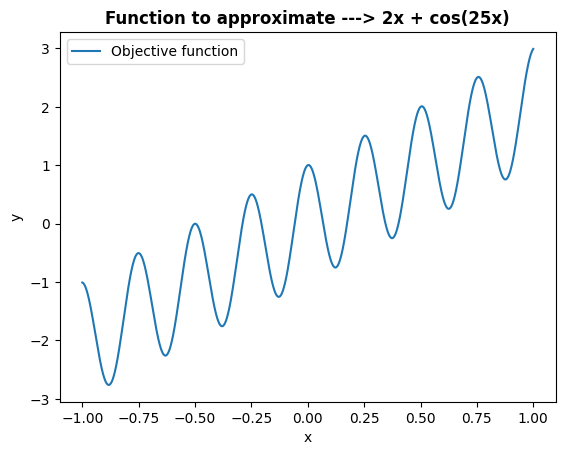

In [ ]:
# Following "arXiv:2303.14151" we wish to predict objective function from x ∈ [-1, 1]
# We define the interval bounds
lower_bound, higher_bound = -1.0, 1.0

# In order to plot the objective function we create 1000 points equispaced on the interval and we apply the objective function to them
X_test = np.linspace(lower_bound, higher_bound, num=1000)
y_test = objective_function(X_test)

# Now we plot the objective function in the interval [-1, 1]
sns.lineplot(x=X_test, y=y_test, label="Objective function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function to approximate ---> 2x + cos(25x)", fontweight='bold')
plt.show()

To create our training set, we define the function **"generate_training_data()"** to obtain a predetermined number of training points.

In [ ]:
'''
The function is given two limits: low and high and a desired number of samples
to create samples that are uniformly distributed over the interval [low, high)
and to which the objective function is applied.

Example of use:
X_train, y_train = generate_training_data(-1, 1, 10)

'''
def generate_training_data(low, high, num_samples):
  # We use "np.random.uniform" to create samples that are uniformly distributed over the interval [low, high)
  X = np.random.uniform(low=low, high=high, size=num_samples)
  # We apply the objective function to the samples
  y = objective_function(X)
  return X, y

In addition, we define a function **"plot_objective_function_and_training_data()"** to plot both the training points and the objective function.

In [ ]:
'''
Function to plot the training data (X_train, y_train) together with the
objective function (X_test, y_test).

'''
def plot_objective_function_and_training_data(X_train, y_train, X_test, y_test):
  # To make sure we are working with 1D arrays
  X_train = X_train.reshape(-1)
  X_test = X_test.reshape(-1)

  # We plot the figure containing the objective function and the training data
  plt.figure()
  # Objective function
  sns.lineplot(x=X_test, y=y_test, label="Objective function")
  # Training data
  sns.scatterplot(x=X_train, y=y_train, s=50, color="black", label="Training data")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend(loc="upper left")
  plt.show()

## Training data

We start by generating our training data (10 samples) and plotting it together with the objective function.

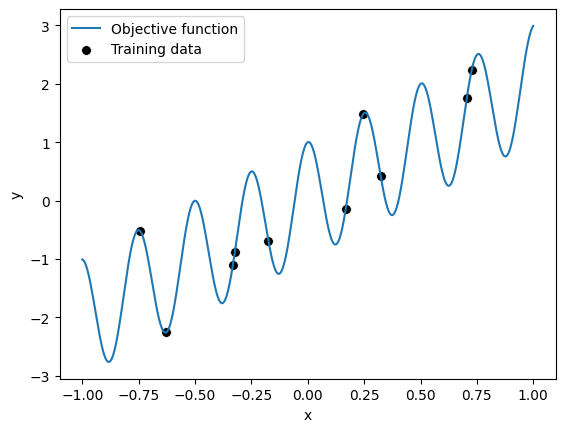

In [ ]:
# Here we generate the training data and we plot them together with the objective function
n_samples = 10
X_train, y_train = generate_training_data(lower_bound, higher_bound, n_samples)
plot_objective_function_and_training_data(X_train, y_train, X_test, y_test)

## Legendre approximation

We define the function **"fit_legendre_polynomial_regression()"** to fit the Legendre polynomials to the samples we have.

In [ ]:
from scipy.special import eval_legendre

'''
Function to perform the polynomial approximation (using Legendre polynomials).
We need the desired degree for the approximation, the training data and the test data.

Recall that the Legendre approximation is based on the following polynomial:
f(x) ≈ a_0*P_0(x) + a_1*P_1(x) + ... + a_n*P_n(x) where P_i(x) is the i-th Legendre polynomial (https://en.wikipedia.org/wiki/Legendre_polynomials).

Example of use:
X_train_poly, y_train_pred, y_test_pred = fit_legendre_polynomial_regression(1, X_train, y_train, X_test)

'''
def fit_legendre_polynomial_regression(degree, X_train, y_train, X_test):
  # In order to approximate the i-th Legendre polynomial, we need all the P_j(x) {j ∈ [1, n]} Legendre polynomials, so we create an array with all these necessary indices
  # "np.arange" is returning an array consisting of [0, degree-1] so we need to sum "1" in every index
  degrees = np.arange(degree) + 1

  # We need to work with 2D arrays to use "eval_legendre" function
  X_train = X_train.reshape(-1, 1)
  X_test = X_test.reshape(-1, 1)

  # We use "eval_legendre" function to evaluate the d-th Legendre polynomial at each training point in X_train (we need all the P_j(x) {j ∈ [1, n]} Legendre polynomials to approximate)
  X_train_poly = np.column_stack([eval_legendre(d, X_train) for d in degrees])
  # We use "eval_legendre" function to evaluate the d-th Legendre polynomial at each test point in X_test
  X_test_poly = np.column_stack([eval_legendre(d, X_test) for d in degrees])

  # In order to calculate w (vector of weights/coefficients for the regression) we need (check slide 15/23 from https://work.caltech.edu/slides/slides03.pdf):
    # 1. We need to compute the pseudo-inverse of X_train_poly (which contains the Legendre features of the polynomial regression)
    # 2. We need to multiply the pseudo-inverse by the y_train data
  w = np.matmul(np.linalg.pinv(X_train_poly), y_train)

  # Here we calculate the predictions of the training and test data with the vector w of weights
  y_train_pred = np.matmul(X_train_poly, w)
  y_test_pred = np.matmul(X_test_poly, w)

  return X_train_poly, y_train_pred, y_test_pred

We also define a function to plot the approximation made by the Legendre polynomials.

In [ ]:
'''
Function to plot the training data (X_train, y_train) together with the
objective function (X_test, y_test) and the fitted function (y_test_pred) for
the specified number of params (degree).

'''
def plot_fitting_approximation(X_train, y_train, X_test, y_test, y_test_pred, degree):
  # To make sure we are working with 1D arrays
  X_train = X_train.reshape(-1)
  X_test = X_test.reshape(-1)

  # We plot the figure containing the objective function, the training data and the fitted function
  plt.figure()
  sns.lineplot(x=X_test, y=y_test, label="Objective function")
  sns.lineplot(x=X_test, y=y_test_pred, label=f"Fitted function - {degree} params")
  sns.scatterplot(x=X_train, y=y_train, s=50, color="black", label="Training data")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.ylim(-3, 3)
  plt.legend(loc="upper left")
  plt.show()

## Training the model

Now, we will approximate the training data using Legendre's polynomial approximation for different degrees of freedom (degrees of the polynomial to be fitted) and calculate both training and test loss.

In [ ]:
output = []

from sklearn.metrics import mean_squared_error

# Number of params we want to use for the approximation (we use [1, 200] params following "arXiv:2303.14151")
degrees = list(range(1, 201))

# For each degree in [1, 200] we calculate the fitted function and see how it fits the objective function by using MSE in training and test.
for degree in degrees:
  X_train_poly, y_train_pred, y_test_pred = fit_legendre_polynomial_regression(degree, X_train, y_train, X_test)

  # We calculate the MSE for the training and test data
  train_loss = mean_squared_error(y_train, y_train_pred)
  test_loss = mean_squared_error(y_test, y_test_pred)

  # We print the degree and both the MSE in training and the MSE in test for that approximation
  print(f"# of parameters = {degree}, train_loss = {train_loss:.4f}, test_loss = {test_loss:.4f}")

  # We save all the results so we can use them lately
  output.append({"# of parameters": degree, "X_train_poly": X_train_poly, "train_loss": train_loss, "test_loss": test_loss, "y_test_pred": y_test_pred})

# We convert the output into a pandas dataframe
output_df = pd.DataFrame(output)

# of parameters = 1, train_loss = 0.3783, test_loss = 0.5670
# of parameters = 2, train_loss = 0.3286, test_loss = 0.6424
# of parameters = 3, train_loss = 0.2883, test_loss = 0.7227
# of parameters = 4, train_loss = 0.2870, test_loss = 0.7146
# of parameters = 5, train_loss = 0.1952, test_loss = 18.6976
# of parameters = 6, train_loss = 0.1833, test_loss = 14.1105
# of parameters = 7, train_loss = 0.1697, test_loss = 101.6349
# of parameters = 8, train_loss = 0.1015, test_loss = 5.1445
# of parameters = 9, train_loss = 0.0074, test_loss = 294295.8908
# of parameters = 10, train_loss = 0.0000, test_loss = 9913.7151
# of parameters = 11, train_loss = 0.0000, test_loss = 302.7952
# of parameters = 12, train_loss = 0.0000, test_loss = 58.2842
# of parameters = 13, train_loss = 0.0000, test_loss = 24.2791
# of parameters = 14, train_loss = 0.0000, test_loss = 14.2189
# of parameters = 15, train_loss = 0.0000, test_loss = 13.0530
# of parameters = 16, train_loss = 0.0000, test_loss = 8.4391

We can check the approximations made for each degree of the Legendre polynomial.

In [ ]:
degree = 1
print("Training data values: ", X_train)
print()
# We know that P_1(x) = x, so the values for X_train_poly using degree = 1 must be the same values as X_train
print("X_train_poly values: ", output_df.loc[degree-1, 'X_train_poly'].reshape(-1))

Training data values:  [ 0.72738184 -0.33254188  0.7050224  -0.32325755 -0.62769519 -0.74258472
 -0.1743211   0.24481597  0.3231326   0.16827867]

X_train_poly values:  [ 0.72738184 -0.33254188  0.7050224  -0.32325755 -0.62769519 -0.74258472
 -0.1743211   0.24481597  0.3231326   0.16827867]


## Some approximations

We now plot some of the approximations obtained by the Legendre polynomials (we note that the higher the degree used for the approximation the smoother the fitted function).

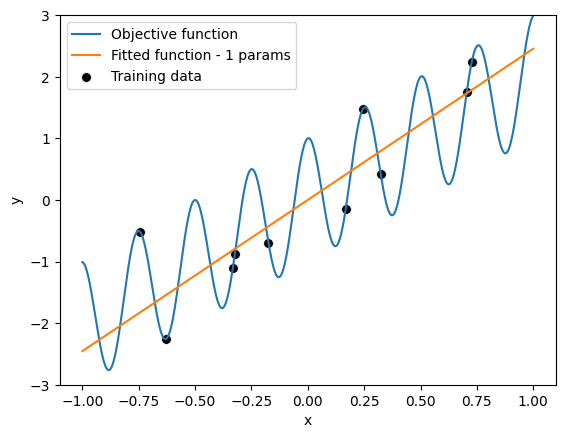

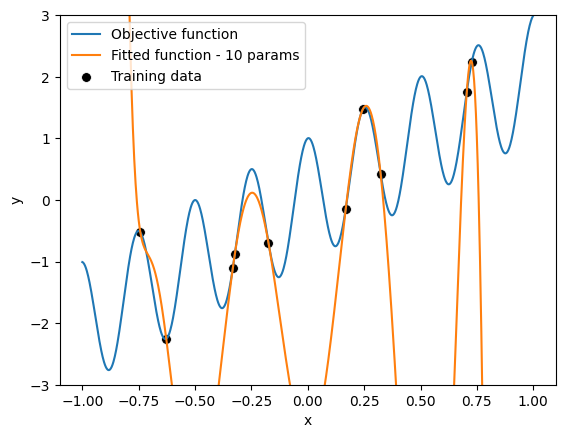

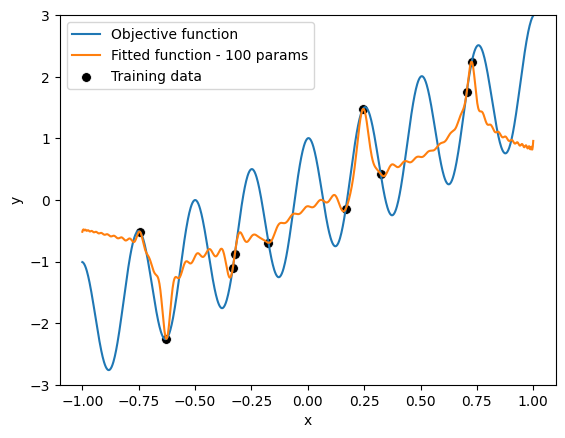

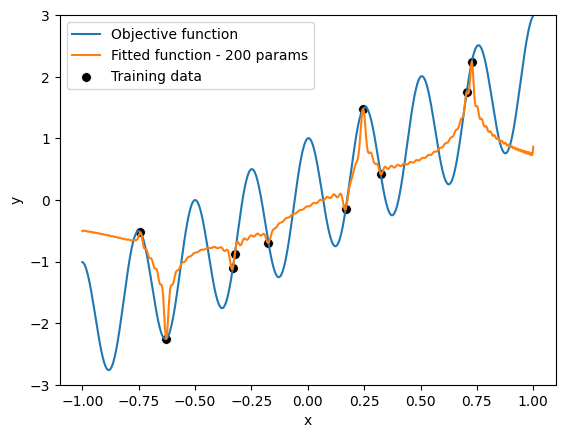

In [ ]:
# We plot the objective function, fitted function and training data
degree = 1
plot_fitting_approximation(X_train, y_train, X_test, y_test, output_df.loc[degree-1, 'y_test_pred'], output_df.loc[degree-1, '# of parameters'])
degree = 10
plot_fitting_approximation(X_train, y_train, X_test, y_test, output_df.loc[degree-1, 'y_test_pred'], output_df.loc[degree-1, '# of parameters'])
degree = 100
plot_fitting_approximation(X_train, y_train, X_test, y_test, output_df.loc[degree-1, 'y_test_pred'], output_df.loc[degree-1, '# of parameters'])
degree = 200
plot_fitting_approximation(X_train, y_train, X_test, y_test, output_df.loc[degree-1, 'y_test_pred'], output_df.loc[degree-1, '# of parameters'])

## Double descent phenomenon

Finally, we plot both the training error curve and the test error curve. We observe how the double descent phenomenon occurs and where the peak of the test error is close to the interpolation threshold (≈ number of training samples).

In [ ]:
'''
Function to plot the double descent phenomenon, using the MSE error metric
(We use the output dataframe to recover all information we need to plot).

'''
def plot_double_descent(output_df, samples):
  plt.figure(figsize=(12, 8))
  # Test loss
  sns.lineplot(
      data=output_df,
      x="# of parameters",
      y="test_loss",
      label="Test",
      marker="D",
  )
  # Train loss
  sns.lineplot(
      data=output_df,
      x="# of parameters",
      y="train_loss",
      label="Train",
      marker="D",
  )
  plt.ylabel("Mean Squared Error (MSE)")
  plt.xlabel("# of Parameters")
  plt.ylim(bottom=1e-3)
  plt.xscale("log")
  plt.yscale("log")
  plt.title("Legendre polynomial regression (train/test error)", fontweight='bold')
  # Interpolation threshold ≈ number of training data samples used
  plt.axvline(x=samples, color="black", linestyle="--", label="Interpolation threshold")
  plt.legend(loc="upper right")

  plt.tight_layout()
  plt.show()

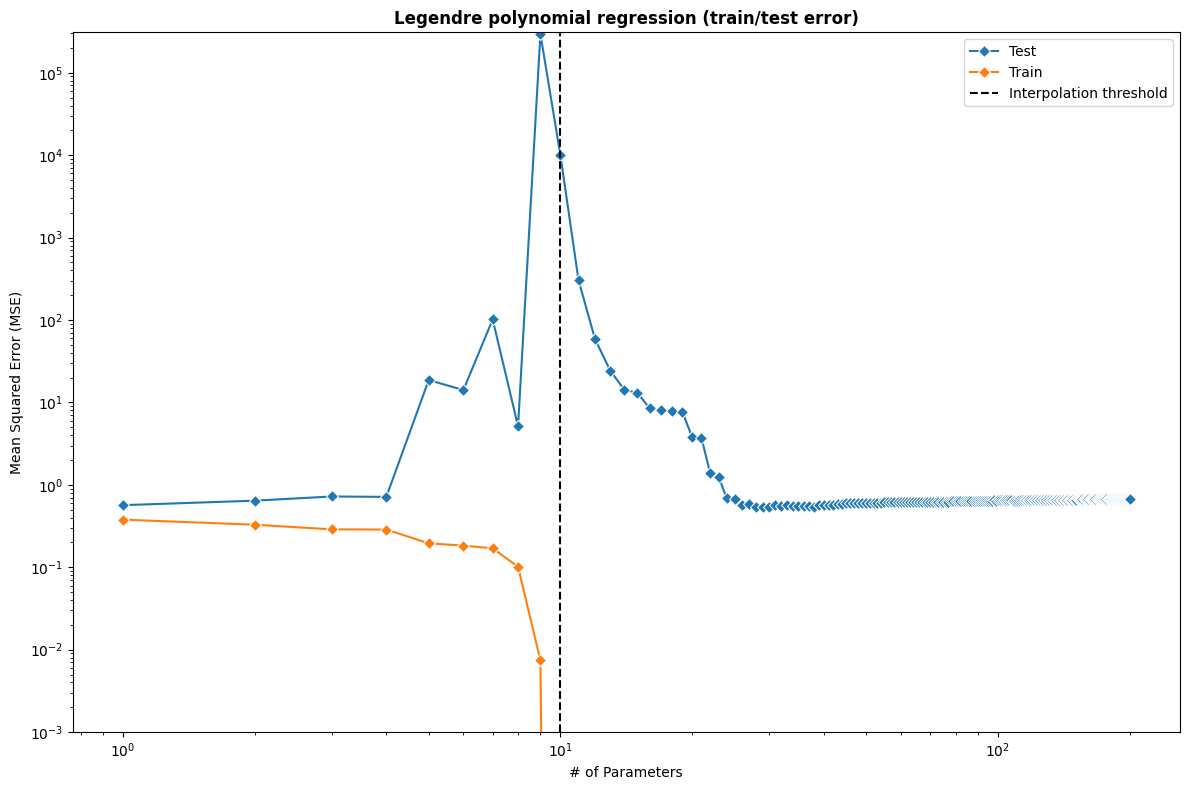

In [ ]:
plot_double_descent(output_df, n_samples)